In [ ]:
import sys
import subprocess
from pathlib import Path

for pkg in ["statsforecast", "statsmodels"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsforecast import StatsForecast
from statsforecast.models import AutoETS, Theta, AutoTheta, SeasonalNaive, MSTL
from statsforecast.utils import ConformalIntervals

from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)


c:\games\!!!studyMaga\2026\AVR\ELECTRODEMAND\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_path = Path("PDB_Load_History_prepared.csv")
if not data_path.exists():
    data_path = Path("/mnt/data/PDB_Load_History_prepared.csv")

df = pd.read_csv(data_path, parse_dates=["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

df.head(), df.shape, df.dtypes


(             datetime   demand
 0 2003-03-01 00:00:00  12863.0
 1 2003-03-01 01:00:00  12389.0
 2 2003-03-01 02:00:00  12155.0
 3 2003-03-01 03:00:00  12072.0
 4 2003-03-01 04:00:00  12160.0,
 (103776, 2),
 datetime    datetime64[ns]
 demand             float64
 dtype: object)

In [3]:
cutoff = df["datetime"].max() - pd.Timedelta(days=365*1.5)
df_1y = df.loc[df["datetime"] > cutoff].copy().reset_index(drop=True)

check = {
    "start": df_1y["datetime"].min(),
    "end": df_1y["datetime"].max(),
    "rows": len(df_1y),
    "span_days": (df_1y["datetime"].max() - df_1y["datetime"].min()).days,
}
print(check)
assert df_1y["datetime"].min() > cutoff
assert df_1y["datetime"].is_monotonic_increasing
assert df_1y["demand"].notna().all()

# out_last_year = Path("PDB_Load_History_last_year.csv")
# df_1y.to_csv(out_last_year, index=False)

df_1y.head()


{'start': Timestamp('2013-07-02 12:00:00'), 'end': Timestamp('2014-12-31 23:00:00'), 'rows': 13140, 'span_days': 547}


,datetime,demand
0,2013-07-02 12:00:00,19980.0
1,2013-07-02 13:00:00,20233.0
2,2013-07-02 14:00:00,20339.0
3,2013-07-02 15:00:00,20456.0
4,2013-07-02 16:00:00,20454.0


In [4]:
# Приведение к формату statsforecast
sf_df = df_1y.rename(columns={"datetime": "ds", "demand": "y"}).copy()
sf_df["unique_id"] = "demand"
sf_df = sf_df[["unique_id", "ds", "y"]]

h = 168 * 2
n_windows = 3
levels = [80, 95]
intervals = ConformalIntervals(n_windows=n_windows, h=h)

models = [
    MSTL(season_length=[24,168], prediction_intervals=intervals),
    SeasonalNaive(season_length=24, prediction_intervals=intervals),
    AutoETS(season_length=24, prediction_intervals=intervals),
    Theta(season_length=24, prediction_intervals=intervals),
    AutoTheta(season_length=24, prediction_intervals=intervals),
]

sf = StatsForecast(models=models, freq="H", n_jobs=-1)
cv = sf.cross_validation(
    df=sf_df,
    h=h,
    n_windows=n_windows,
    step_size=h,
    level=levels,
)

cv.head()


,unique_id,ds,cutoff,y,MSTL,MSTL-lo-95,MSTL-lo-80,MSTL-hi-80,MSTL-hi-95,SeasonalNaive,SeasonalNaive-lo-95,SeasonalNaive-lo-80,SeasonalNaive-hi-80,SeasonalNaive-hi-95,AutoETS,AutoETS-lo-95,AutoETS-lo-80,AutoETS-hi-80,AutoETS-hi-95,Theta,Theta-lo-80,Theta-hi-80,Theta-lo-95,Theta-hi-95,AutoTheta,AutoTheta-lo-80,AutoTheta-hi-80,AutoTheta-lo-95,AutoTheta-hi-95
0,demand,2014-11-20 00:00:00,2014-11-19 23:00:00,12306.0,12395.351510,12376.403208,12380.151083,12410.551937,12414.299813,12602.0,12354.500,12383.0,12821.0,12849.500,12606.393237,12281.377124,12335.737274,12877.049200,12931.409350,12219.695880,12161.017970,12278.373790,12154.930534,12284.461226,12219.695880,12161.017970,12278.373790,12154.930534,12284.461226
1,demand,2014-11-20 01:00:00,2014-11-19 23:00:00,11835.0,11837.991366,11718.789485,11722.714173,11953.268559,11957.193247,12231.0,11933.500,11980.0,12482.0,12528.500,12245.239056,11271.983274,11524.575368,12965.902744,13218.494838,11724.205935,11654.077981,11794.333889,11652.659614,11795.752256,11724.205935,11654.077981,11794.333889,11652.659614,11795.752256
2,demand,2014-11-20 02:00:00,2014-11-19 23:00:00,11626.0,11800.861836,11752.506008,11761.554425,11840.169246,11849.217664,12084.0,11761.875,11818.5,12349.5,12406.125,12083.524695,11570.824857,11621.270231,12545.779159,12596.224532,11385.028364,11269.685298,11500.371431,11237.328230,11532.728499,11385.028364,11269.685298,11500.371431,11237.328230,11532.728499
3,demand,2014-11-20 03:00:00,2014-11-19 23:00:00,11637.0,11826.813861,11756.815079,11771.798506,11881.829216,11896.812642,12141.0,11808.375,11863.5,12418.5,12473.625,12116.917645,11669.932700,11699.115260,12534.720031,12563.902591,11291.715863,11111.628600,11471.803126,11065.033265,11518.398461,11291.715863,11111.628600,11471.803126,11065.033265,11518.398461
4,demand,2014-11-20 04:00:00,2014-11-19 23:00:00,11994.0,12202.861140,12118.710745,12134.660786,12271.061493,12287.011534,12543.0,12173.000,12245.0,12841.0,12913.000,12469.237230,12091.035844,12107.187192,12831.287268,12847.438616,11496.984394,11162.962311,11831.006478,11091.840549,11902.128239,11496.984394,11162.962311,11831.006478,11091.840549,11902.128239


In [5]:
# Сводная таблица качества backtesting
model_names = ["AutoETS", "Theta", "AutoTheta", "SeasonalNaive", "MSTL"]

def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.where(np.abs(y_true) < 1e-8, np.nan, np.abs(y_true))
    return np.nanmean(np.abs((y_true - y_pred) / denom)) * 100

def safe_smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom < 1e-8, np.nan, denom)
    return np.nanmean(2 * np.abs(y_true - y_pred) / denom) * 100

rows = []
for m in model_names:
    err = cv["y"] - cv[m]
    lo80 = cv[f"{m}-lo-80"]
    hi80 = cv[f"{m}-hi-80"]
    lo95 = cv[f"{m}-lo-95"]
    hi95 = cv[f"{m}-hi-95"]

    rows.append({
        "model": m,
        "RMSE": float(np.sqrt(np.mean(err**2))),
        "MAE": float(np.mean(np.abs(err))),
        "MAPE_%": float(safe_mape(cv["y"], cv[m])),
        "sMAPE_%": float(safe_smape(cv["y"], cv[m])),
        "coverage_80": float(np.mean((cv["y"] >= lo80) & (cv["y"] <= hi80))),
        "coverage_95": float(np.mean((cv["y"] >= lo95) & (cv["y"] <= hi95))),
        "avg_width_95": float(np.mean(hi95 - lo95)),
    })

metrics = pd.DataFrame(rows).sort_values(["RMSE", "MAE"]).reset_index(drop=True)
metrics


,model,RMSE,MAE,MAPE_%,sMAPE_%,coverage_80,coverage_95,avg_width_95
0,MSTL,1115.483979,867.487450,6.257264,6.108269,0.523810,0.608135,2154.050367
1,Theta,1233.530312,984.732831,6.997887,6.871338,0.634921,0.730159,3047.584535
2,AutoTheta,1233.530312,984.732831,6.997887,6.871338,0.634921,0.730159,3047.584535
3,AutoETS,1262.374005,969.831799,7.116135,6.792327,0.558532,0.655754,2704.578440
4,SeasonalNaive,1296.475354,969.495040,7.166561,6.793982,0.602183,0.694444,2794.789683


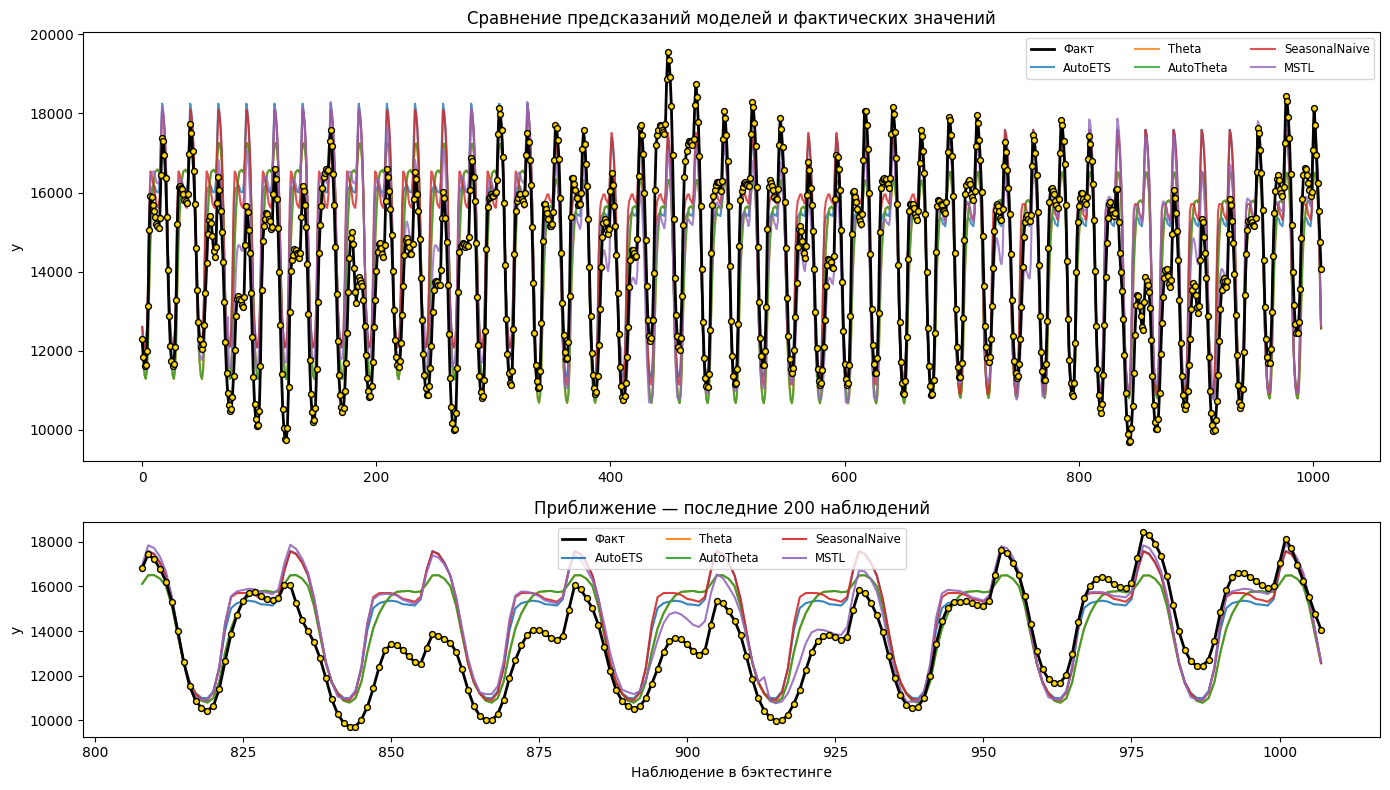

In [6]:
import matplotlib.pyplot as plt
zoom_len = min(200, len(cv))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14,8), gridspec_kw={'height_ratios':[2,1]})
x = np.arange(len(cv))

ax1.plot(x, cv['y'].to_numpy(), label='Факт', color='black', linewidth=2, zorder=10)
ax1.scatter(x, cv['y'].to_numpy(), color='gold', edgecolor='black', s=18, zorder=11)
colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple']
for m, c in zip(model_names, colors):
    if m in cv.columns:
        ax1.plot(x, cv[m].to_numpy(), label=m, color=c, alpha=0.8)
        
ax1.set_title('Сравнение предсказаний моделей и фактических значений')
ax1.set_ylabel('y')
ax1.legend(ncol=3, fontsize='small')

start = max(0, len(cv) - zoom_len)
xz = np.arange(start, len(cv))
ax2.plot(xz, cv['y'].to_numpy()[start:], label='Факт', color='black', linewidth=2, zorder=10)
ax2.scatter(xz, cv['y'].to_numpy()[start:], color='gold', edgecolor='black', s=18, zorder=11)
for m, c in zip(model_names, colors):
    if m in cv.columns:
        ax2.plot(xz, cv[m].to_numpy()[start:], label=m, color=c, alpha=0.9)

ax2.set_title(f'Приближение — последние {zoom_len} наблюдений')
ax2.set_xlabel('Наблюдение в бэктестинге')
ax2.set_ylabel('y')
ax2.legend(ncol=3, fontsize='small')
plt.tight_layout()
plt.show()

In [7]:
# Выбор лучшей модели по RMSE и анализ ее остатков
best_model = metrics.iloc[0]["model"]
residuals = cv["y"] - cv[best_model]

print(f"Лучшая модель по RMSE: {best_model}")
print(residuals.describe())

lb = acorr_ljungbox(residuals.dropna(), lags=[24, 48, 72], return_df=True)
lb


Лучшая модель по RMSE: MSTL
count    1008.000000
mean     -146.130362
std      1106.419845
min     -4311.932842
25%      -896.797696
50%        16.135583
75%       609.445091
max      2521.028032
dtype: float64


,lb_stat,lb_pvalue
24,14847.553864,0.0
48,21764.867894,0.0
72,26953.398642,0.0


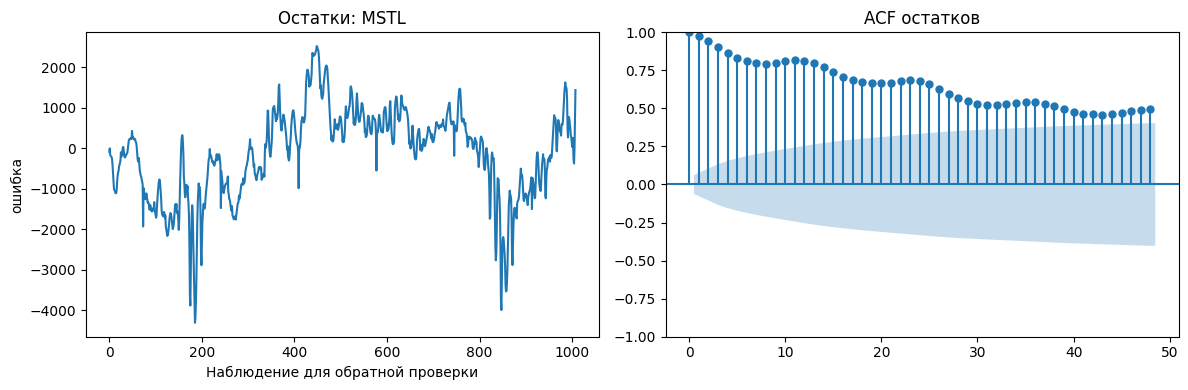

In [8]:
# Краткая визуальная проверка остатков
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(residuals.to_numpy())
axes[0].set_title(f"Остатки: {best_model}")
axes[0].set_xlabel("Наблюдение для обратной проверки")
axes[0].set_ylabel("ошибка")

plot_acf(residuals.dropna(), lags=48, ax=axes[1])
axes[1].set_title("ACF остатков")
plt.tight_layout()
plt.show()
